In [4]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm
from pathlib import Path 
import torch 

In [13]:
# Get model activation files 

out_dir = Path('binaural_model_attn_stage_reps/')
# paths = list(out_dir.glob('*model_activations_0dB.h5'))

# path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB.h5")
files_to_run = list(Path('binaural_model_attn_stage_reps/word_task_half_co_loc_v07/').glob("*v3*"))

In [15]:
files_to_run

[PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_-5dB_w_cues_v3.h5'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_-8dB_w_cues_v3.h5'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3.h5'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_5dB_w_cues_v3.h5'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_8dB_w_cues_v3.h5')]

## Run full thing and save - will move to script in future 

In [18]:
# for path in files_to_run:
#     with h5py.File(path, 'r') as f:
#         # layer_names = [key.split("_mixture")[0] for key in f.keys() if "mixture" in key]
        
#         layer_names = [key.split("_mixture")[0] for key in f.keys() if "mixture" in key and 'acc' not in key]

#         print(layer_names)
#         fg_corr_results = {}
#         bg_corr_results = {}
        
#         out_name = f"{path.stem}_corrs.pkl"
#         # Save results as dict
#         out_name = out_dir / out_name
#         print(out_name)
#         N_acts = f[f"{layer_names[0]}_mixture"].shape[0]
#         for layer in layer_names:
#             mixture_acts = f[f"{layer}_mixture"]
#             target_acts = f[f"{layer}_fg"]
#             bg_acts = f[f"{layer}_bg"]

#             fg_corr_results[layer] = []
#             bg_corr_results[layer] = []

#             for i in tqdm(range(N_acts), desc=f"Getting activations for {layer}", leave=False):
#                 fg_corr_results[layer].append(stats.pearsonr(target_acts[i], mixture_acts[i])[0])
#                 bg_corr_results[layer].append(stats.pearsonr(bg_acts[i], mixture_acts[i])[0])
            
#             # set type as float32
#             fg_corr_results[layer] = np.array(fg_corr_results[layer], dtype=np.float32)
#             bg_corr_results[layer] = np.array(bg_corr_results[layer], dtype=np.float32)
            
#         out_dict = dict(fg_corr_results=fg_corr_results, bg_corr_results=bg_corr_results)

#         with open(out_name ,'wb') as f:
#             pickle.dump(out_dict, f)

In [19]:
# with h5py.File(path, 'r') as f:
#     print(f.keys())

In [21]:
## Make layer plot 

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import pickle 
import pandas as pd
import re


In [26]:
# put results into dataframe for easy plotting:


files_to_run = list(Path('binaural_model_attn_stage_reps/word_task_half_co_loc_v07/').glob("*v3_corrs.pkl"))

dfs = []
for file in files_to_run:
    snr = int(re.search('(-?\d+)dB', file.stem).group(0).strip('dB'))
    with open(file, 'rb') as f:
        results = pickle.load(f)
        fg_corr_results = results['fg_corr_results']
        bg_corr_results = results['bg_corr_results']
        for layer in fg_corr_results.keys():
            df = pd.DataFrame.from_dict({'fg_corrs':fg_corr_results[layer],
                                        'bg_corrs':bg_corr_results[layer],
                                        # 'acc': trial_accs, 
                                        'snr': [snr] * len(fg_corr_results[layer]),
                                        'layer': [layer] * len(fg_corr_results[layer])})
                    
            dfs.append(df)
corr_results = pd.concat(dfs)

corr_results['layer'] = corr_results['layer'].str.replace('_block_', '')

results = pd.melt(corr_results, id_vars =['layer', 'snr'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")


In [27]:
results

,layer,snr,Stream,Pearson's r
0,cochleagram,-5,fg_corrs,0.588678
1,cochleagram,-5,fg_corrs,0.529906
2,cochleagram,-5,fg_corrs,0.618159
3,cochleagram,-5,fg_corrs,0.555471
4,cochleagram,-5,fg_corrs,0.653612
...,...,...,...,...
8995,relufc,8,bg_corrs,0.202254
8996,relufc,8,bg_corrs,0.293404
8997,relufc,8,bg_corrs,0.268671
8998,relufc,8,bg_corrs,0.200596


In [28]:
# summarize results and rename columns to Pearson's r and two SEM

summary_results = results.groupby(['layer', 'snr', 'Stream']).agg(['mean', 'sem']).reset_index()
summary_results.columns = ['layer', 'snr', 'Stream', "Pearson's r", 'two SEM']
# rename columns
summary_results = summary_results.rename(columns={"Stream": "Model"})

summary_results['two SEM'] = 2*summary_results['two SEM'] # actually get 2 sem 
# upate stream names 
summary_results['Model'] = summary_results['Model'].str.replace('fg_corrs', 'corr(target,mixture)')
summary_results['Model'] = summary_results['Model'].str.replace('bg_corrs', 'corr(background,mixture)')
# summary_results
# combine null_corr_df and summary_results
# combined_results = pd.concat([summary_results, null_corr_df], ignore_index=True)
# combined_results

Text(0.5, 0.98, 'Stream activation correlations with attention')

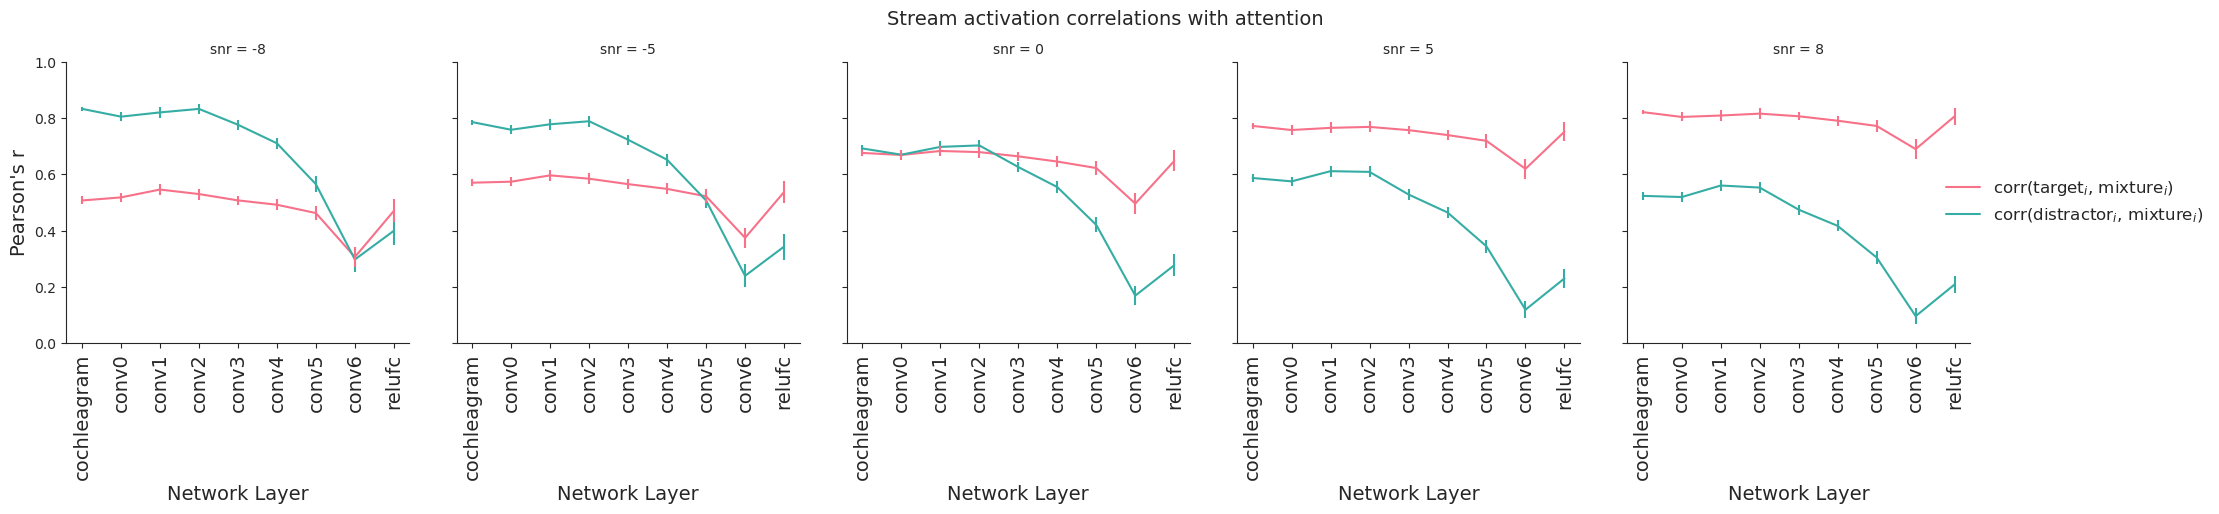

In [39]:
## Plot summary_results df 
sns.set_style('ticks')
order = np.sort(results.layer.unique())

summary_results['Model'].replace('corr(target,mixture)', 'corr(target$_i$, mixture$_i$)', inplace=True)
summary_results['Model'].replace('corr(background,mixture)', 'corr(distractor$_i$, mixture$_i$)', inplace=True)

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)',]#  'corr(target$_i$, target$_j$)', 'corr(target$_i$, mixture$_j$)']
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[0],
                'corr(distractor$_i$, mixture$_i$)': palette[1],}
                # 'corr(target$_i$, target$_j$)': 'k',
                # 'corr(target$_i$, mixture$_j$)': 'grey'}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-',}
                #    'corr(target$_i$, target$_j$)': '--',
                #    'corr(target$_i$, mixture$_j$)': '--'}  

p = sns.relplot(kind='line',data=summary_results, x='layer', y="Pearson's r", col='snr', #order=order, 
              hue = 'Model', hue_order = hue_order, palette=palette_dict, 
              height=4, aspect=1, 
              errorbar=None, seed=1)

# add error bars to p 
# iterate through each facet of the facetgrid
for snr, ax in p.axes_dict.items():
    # select the data for the facet
    group = summary_results[summary_results['snr'].eq(snr)]
    # select the data for each hue group
    for model, data in group.groupby('Model'):
        # get the error bars
        yerr = data['two SEM'].values
        # get the x values
        x = data['layer'].values
        # get the y values
        y = data["Pearson's r"].values
        # plot the error bars
        ax.errorbar(x, y, yerr=yerr, fmt='none', color=palette_dict[model],  capthick=2)
        # p.axes[0][0].fill_between(x, y-yerr, y+yerr, alpha=0.25, color=palette_dict[model], linewidth=0)


fontsize=14


p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1, .5),
                frameon=False,
                title='', fontsize=fontsize-2)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Stream activation correlations with attention", size=fontsize, )



Text(0.5, 0.98, 'Stream activation correlations with attention')

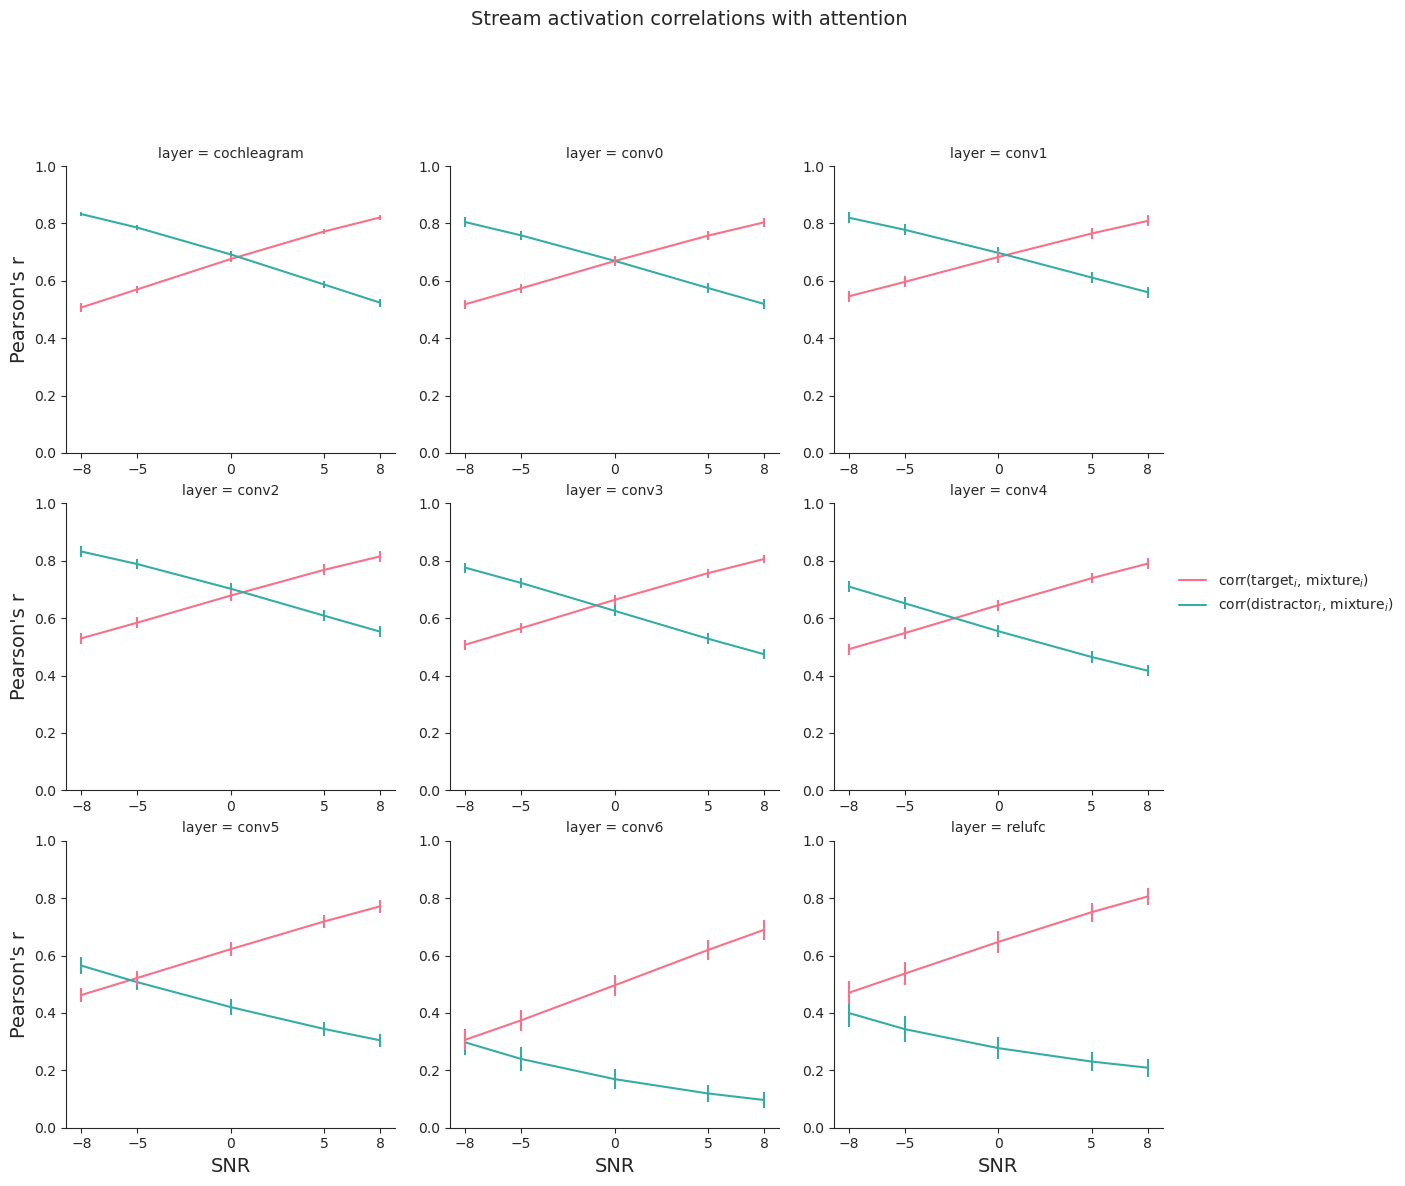

In [53]:
## Plot summary_results df 
sns.set_style('ticks')
order = np.sort(results.layer.unique())

summary_results['Model'].replace('corr(target,mixture)', 'corr(target$_i$, mixture$_i$)', inplace=True)
summary_results['Model'].replace('corr(background,mixture)', 'corr(distractor$_i$, mixture$_i$)', inplace=True)

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)',]#  'corr(target$_i$, target$_j$)', 'corr(target$_i$, mixture$_j$)']
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[0],
                'corr(distractor$_i$, mixture$_i$)': palette[1],}
                # 'corr(target$_i$, target$_j$)': 'k',
                # 'corr(target$_i$, mixture$_j$)': 'grey'}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-',}
                #    'corr(target$_i$, target$_j$)': '--',
                #    'corr(target$_i$, mixture$_j$)': '--'}  

p = sns.relplot(kind='line', data=summary_results, x='snr', y="Pearson's r",
              col='layer', col_wrap=3,#order=order, 
              hue = 'Model', hue_order = hue_order, palette=palette_dict, 
              height=4, aspect=1, facet_kws={'sharey': False, 'sharex': False},
              errorbar=None, seed=1)

# add error bars to p 
# iterate through each facet of the facetgrid
for layer, ax in p.axes_dict.items():
    # select the data for the facet
    group = summary_results[summary_results['layer'].eq(layer)]
    # select the data for each hue group
    for model, data in group.groupby('Model'):
        # get the error bars
        yerr = data['two SEM'].values
        # get the x values
        x = data['snr'].values
        # get the y values
        y = data["Pearson's r"].values
        # plot the error bars
        ax.errorbar(x, y, yerr=yerr, fmt='none', color=palette_dict[model],  capthick=2)
        # p.axes[0][0].fill_between(x, y-yerr, y+yerr, alpha=0.25, color=palette_dict[model], linewidth=0)


fontsize=14


p.set_axis_labels("SNR", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

x_tick_locs = summary_results.snr.unique()

for ax in p.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    # ax.set_xticklabels(labels=x_tick_labels)
# g.set_yticklabels(size=fontsize)
    
p._legend.set_title('')
# plt.yscale('log')
# sns.move_legend(p,
#                # loc="best", #bbox_to_anchor=(1, .5),
#                 frameon=False,
#                 title='', fontsize=fontsize-2)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Stream activation correlations with attention", size=fontsize, )



Text(0.5, 0.98, 'Stream activation correlations with attention')

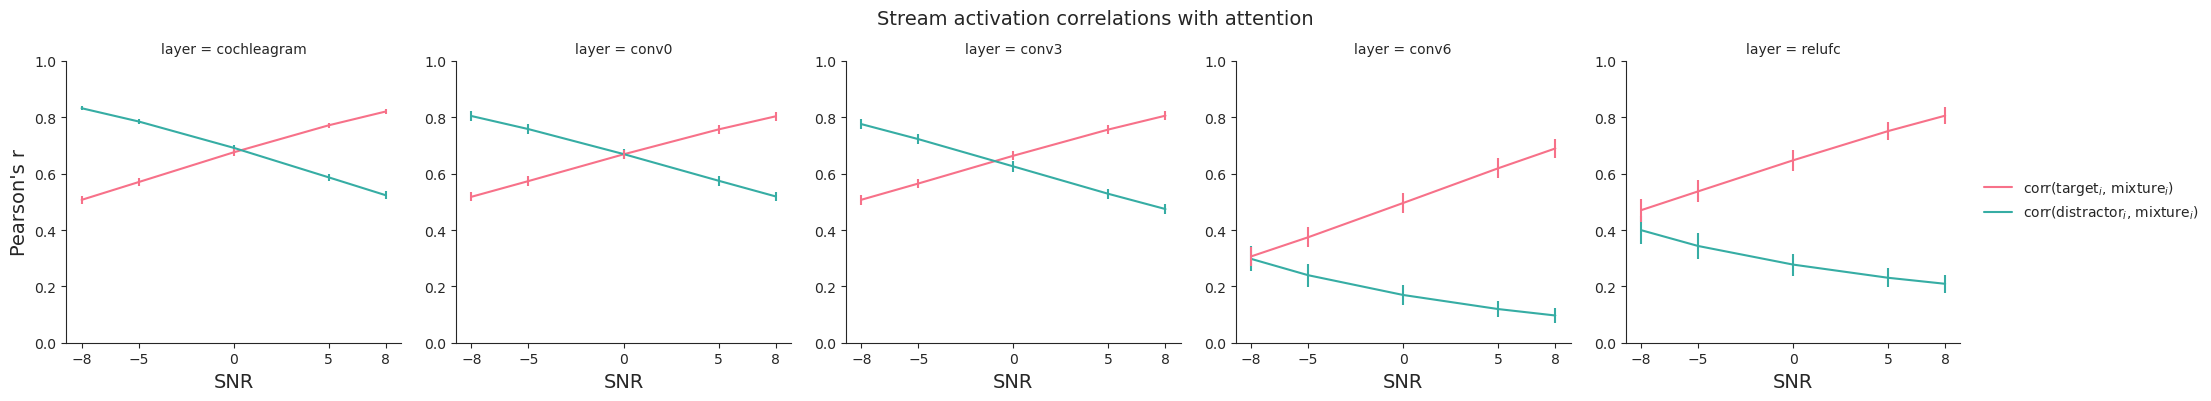

In [55]:
## Plot summary_results df 
sns.set_style('ticks')
order = np.sort(results.layer.unique())

to_plot = summary_results[summary_results.layer.isin(['cochleagram', 'conv0', 'conv3', 'conv6', 'relufc'])]
hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)',]#  'corr(target$_i$, target$_j$)', 'corr(target$_i$, mixture$_j$)']
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[0],
                'corr(distractor$_i$, mixture$_i$)': palette[1],}
                # 'corr(target$_i$, target$_j$)': 'k',
                # 'corr(target$_i$, mixture$_j$)': 'grey'}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-',}
                #    'corr(target$_i$, target$_j$)': '--',
                #    'corr(target$_i$, mixture$_j$)': '--'}  

p = sns.relplot(kind='line', data=to_plot, x='snr', y="Pearson's r",
              col='layer',#order=order, 
              hue = 'Model', hue_order = hue_order, palette=palette_dict, 
              height=4, aspect=1, facet_kws={'sharey': False, 'sharex': False},
              errorbar=None, seed=1)

# add error bars to p 
# iterate through each facet of the facetgrid
for layer, ax in p.axes_dict.items():
    # select the data for the facet
    group = summary_results[summary_results['layer'].eq(layer)]
    # select the data for each hue group
    for model, data in group.groupby('Model'):
        # get the error bars
        yerr = data['two SEM'].values
        # get the x values
        x = data['snr'].values
        # get the y values
        y = data["Pearson's r"].values
        # plot the error bars
        ax.errorbar(x, y, yerr=yerr, fmt='none', color=palette_dict[model],  capthick=2)
        # p.axes[0][0].fill_between(x, y-yerr, y+yerr, alpha=0.25, color=palette_dict[model], linewidth=0)


fontsize=14


p.set_axis_labels("SNR", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

x_tick_locs = summary_results.snr.unique()

for ax in p.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    # ax.set_xticklabels(labels=x_tick_labels)
# g.set_yticklabels(size=fontsize)
    
p._legend.set_title('')
# plt.yscale('log')
# sns.move_legend(p,
#                # loc="best", #bbox_to_anchor=(1, .5),
#                 frameon=False,
#                 title='', fontsize=fontsize-2)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Stream activation correlations with attention", size=fontsize, )

